/tmp/ipykernel_122730/4196821493.py:199: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = spearmanr(measured_values, predicted_values)
/tmp/ipykernel_122730/4196821493.py:199: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = spearmanr(measured_values, predicted_values)
/tmp/ipykernel_122730/4196821493.py:199: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = spearmanr(measured_values, predicted_values)
/tmp/ipykernel_122730/4196821493.py:199: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = spearmanr(measured_values, predicted_values)
/tmp/ipykernel_122730/4196821493.py:199: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = spearmanr(measured_values, predicted_values)
/tmp/

KeyboardInterrupt: 

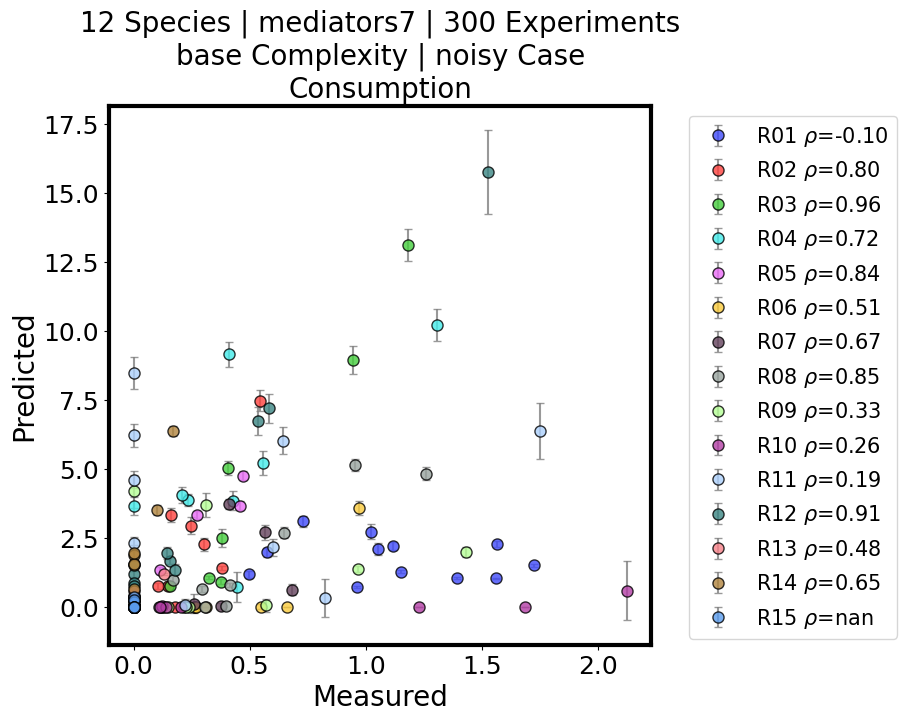

In [ ]:
import numpy as np
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from scipy.stats import linregress, pearsonr, spearmanr, norm
from scipy.spatial import procrustes
from sklearn.metrics import roc_curve, auc
import time
import distinctipy

from glob import glob
import re

import pickle as pkl
import sys
import os
import gc

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)
from nsm.nsm import *

params = {'legend.fontsize': 15,
          'figure.figsize': (7, 7),
          'axes.labelsize': 20,
          'axes.titlesize': 20,
          'axes.linewidth': 3,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'svg.fonttype':'none'}
plt.rcParams.update(params)
np.random.seed(12345)

mediators_ = {
    'mediators1': ['R01'],
    'mediators2': ['R09'],
    'mediators3': ['R01', 'R05'],
    'mediators4': ['R01', 'R13'],
    'mediators5': ['R01', 'R03', 'R07', 'R10', 'R13'],
    'mediators6': ['R01','R03','R05','R07','R08','R09','R10','R12','R13','R15'],
    'mediators7': ['R01','R02','R03','R04','R05','R06','R07','R08','R09','R10','R11','R12','R13','R14','R15']
}

model_paths = glob('results/parameters/parameter_*.csv')
model_paths.sort()
log_file = 'processed_parameters.txt'

for model_path in model_paths:
    if os.path.exists(log_file):
        with open(log_file, 'r') as f:
            processed_files = set(line.strip() for line in f)
    else:
        processed_files = set()
    if model_path in processed_files:
        continue
    args = model_path.split('_')
    sps  = int(args[1].split('s')[0])
    rscs = int(args[1].split('s')[-1].split('r')[0])
    cplx = args[2]
    cs   = args[3]
    exps = int(args[4].replace('exps',''))
    md   = args[5]
    k    = int(args[6].split('k')[0])

    species   = [f'S{i:02d}' for i in range(1, sps+1)]
    resources = [f'R{i:02d}' for i in range(1, rscs+1)]
    mediators = mediators_[md]

    variables = species + mediators
    md_indx = [resources.index(m) for m in mediators]
    
    param_df_summary = pd.read_csv(f'results/parameters/parameter_{sps}s{rscs}r_{cplx}_{cs}_{exps}exps_{md}_{k}k.csv')

    param_df_summary_c = param_df_summary[param_df_summary['Parameter'] == 'Consumption'].copy()
    est_C_iα = param_df_summary_c.pivot_table(index='Target', columns='Source', values='Mean').reset_index()
    est_C_iα.columns.name = None
    est_C_iα.set_index('Target', inplace=True)
    est_C_iα.index.name = None
    est_C_iα.sort_index(axis=0, inplace=True)
    est_C_iα_std = param_df_summary_c.pivot_table(index='Target', columns='Source', values='Std').reset_index()
    est_C_iα_std.columns.name = None
    est_C_iα_std.set_index('Target', inplace=True)
    est_C_iα_std.index.name = None
    est_C_iα_std.sort_index(axis=0, inplace=True)

    param_df_summary_p = param_df_summary[param_df_summary['Parameter'] == 'Production'].copy()
    est_P_iα = param_df_summary_p.pivot_table(index='Source', columns='Target', values='Mean').reset_index()
    est_P_iα.columns.name = None
    est_P_iα.set_index('Source', inplace=True)
    est_P_iα.index.name = None
    est_P_iα.sort_index(axis=0, inplace=True)

    # prep parameter files
    w = np.array([1] + 4*[0.7] + 3*[0.5] + 2*[0.7] + 2*[0.4] + 3*[0.5])
    l = np.array([0.7] * 15)

    c_iα = pd.read_csv(f'parameters/consumer_preference_{sps}s{rscs}r_{cplx}.csv', index_col=0)
    sp_map = {'S{:01d}'.format(i): 'S{:02d}'.format(i+1) for i in range(sps)}
    rcs_map = {'R{:01d}'.format(i): 'R{:02d}'.format(i+1) for i in range(rscs)}
    rpl_map = {**sp_map, **rcs_map}
    c_iα.columns = c_iα.columns.to_series().replace(rpl_map)
    c_iα.index = c_iα.index.to_series().replace(rpl_map)
    D_iαβ = np.load(f'parameters/metabolic_matrix_{sps}s{rscs}r_{cplx}.npy')
    P_iαβ = (l * w) * c_iα.values[:, np.newaxis, :] * D_iαβ

    C_iα = c_iα.loc[species, mediators]
    P_iα = pd.DataFrame((P_iαβ.sum(axis=2)/ w)[:, md_indx], columns=mediators, index=species)

    # fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    fig, axs = plt.subplots()
    # Plot MiCRM Ground Truth
    # to_plot = C_iα.copy()
    # to_plot = to_plot.loc[species, mediators]
    # sns.heatmap(to_plot,
    #             cmap='Greys',
    #             square=True,
    #             cbar_kws={"shrink": 0.65},
    #             ax=axs[0])
    # axs[0].set_title('MiCRM Ground Truth\nConsumption matrix ($C_{j\\alpha}$)')
    # axs[0].set_xlabel('Mediators')
    # axs[0].set_ylabel('Species')

    # Plot NSM Estimation
    to_plot = est_C_iα.copy()
    to_plot = to_plot.loc[species, mediators]
    sns.heatmap(to_plot,
                cmap='Greys',
                square=True,
                cbar_kws={"shrink": 0.625},
                ax=axs[1])
    axs[1].set_title('NSM Estimation\nConsumption matrix ($C_{j\\alpha}$)')
    axs[1].set_xlabel('Mediators')
    axs[1].set_ylabel('Species')

    fig.savefig(f'plots/parameters/values/consumption_matrix_{sps}s{rscs}r_{cplx}_{cs}_{exps}exps_{md}_{k}k.png', dpi=300, bbox_inches='tight')
    plt.close(fig)

    # fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    fig, axs = plt.subplots()
    # Plot MiCRM Ground Truth
    # to_plot = P_iα.copy()
    # to_plot = to_plot.loc[species, mediators]5
    # sns.heatmap(to_plot,
    #             cmap='Greys',
    #             square=True,
    #             cbar_kws={"shrink": 0.625},
    #             ax=axs[0])
    # axs[0].set_title('MiCRM Ground Truth\nProduction matrix ($P_{j\\alpha}$)')
    # axs[0].set_xlabel('Mediators')
    # axs[0].set_ylabel('Species')

    # Plot NSM Estimation
    # to_plot = est_P_iα.copy()
    # to_plot = to_plot.loc[species, mediators]
    # sns.heatmap(to_plot,
    #             cmap='Greys',
    #             square=True,
    #             cbar_kws={"shrink": 0.625},
    #             ax=axs[1])
    # axs[1].set_title('NSM Estimation\nProduction matrix ($P_{j\\alpha}$)')
    # axs[1].set_xlabel('Mediators')
    # axs[1].set_ylabel('Species')

    # fig.savefig(f'plots/parameters/values/production_matrix_{sps}s{rscs}r_{cplx}_{cs}_{exps}exps_{md}_{k}k.png', dpi=300, bbox_inches='tight')
    # plt.close(fig)

    correlations = {
        'species': [], 
        'resources': [], 
        'complexity': [],
        'mediators': [], 
        'case': [], 
        'experiments': [],
        'k': [], 
        'variable': [],
        'type': [],
        'correlation': []
    }

    colors_mds = distinctipy.get_colors(len(mediators), pastel_factor=0.3)
    
    fig, ax = plt.subplots()
    for i, mediator in enumerate(est_C_iα.columns):
        # Calculate Pearson correlation coefficient
        measured_values = C_iα.loc[:, mediator].values
        predicted_values = est_C_iα.loc[:, mediator].values
        predicted_errors = est_C_iα_std.loc[:, mediator].values
        correlation, _ = spearmanr(measured_values, predicted_values)

        correlations['species'].append(sps)
        correlations['resources'].append(rscs)
        correlations['complexity'].append(cplx)
        correlations['mediators'].append(md)
        correlations['case'].append(cs)
        correlations['experiments'].append(exps)
        correlations['k'].append(k)
        correlations['variable'].append(mediator)
        correlations['type'].append('Consumption')
        correlations['correlation'].append(correlation)

        # Plot the parity plot
        plt.errorbar(measured_values, predicted_values, yerr=predicted_errors, color=colors_mds[i % len(colors_mds)],
                    fmt='o', ecolor='gray', markersize=8, markeredgecolor='k', capsize=3, label=f'{mediator} $\\rho$={correlation:.2f}', alpha=0.8)

        # Add legend with Pearson correlation coefficient
        # plt.legend(['Line of Perfect Agreement', f'r = {correlation:.2f}'])
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
        # Set labels and title
        plt.xlabel(f'Measured')
        plt.ylabel(f'Predicted')
        plt.title(f'{sps} Species | {md} | {exps} Experiments\n{cplx} Complexity | {cs} Case\nConsumption')

    fig.savefig(f'plots/parameters/correlations/consumption_{sps}s{rscs}r_{cplx}_{cs}_{exps}exps_{md}_{k}k.png', dpi=300, bbox_inches='tight')
    plt.close(fig)

    # fig, ax = plt.subplots()
    # for i, mediator in enumerate(est_P_iα.columns):
    #     # Calculate Pearson correlation coefficient
    #     measured_values = P_iα.loc[:, mediator].values
    #     predicted_values = est_P_iα.loc[:, mediator].values
    #     correlation, _ = spearmanr(measured_values, predicted_values)

    #     correlations['species'].append(sps)
    #     correlations['resources'].append(rscs)
    #     correlations['complexity'].append(cplx)
    #     correlations['mediators'].append(md)
    #     correlations['case'].append(cs)
    #     correlations['experiments'].append(exps)
    #     correlations['k'].append(k)
    #     correlations['variable'].append(mediator)
    #     correlations['type'].append('Production')
    #     correlations['correlation'].append(correlation)

    #     # Plot the parity plot
    #     plt.errorbar(measured_values, predicted_values, yerr=predicted_errors, color=colors_mds[i % len(colors_mds)],
    #                 fmt='o', ecolor='gray', markersize=8, markeredgecolor='k', capsize=3, label=f'{mediator} $\\rho$={correlation:.2f}', alpha=0.8)

    #     # Add legend with Pearson correlation coefficient
    #     # plt.legend(['Line of Perfect Agreement', f'r = {correlation:.2f}'])
    #     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
    #     # Set labels and title
    #     plt.xlabel(f'Measured')
    #     plt.ylabel(f'Predicted')
    #     plt.title(f'{sps} Species | {md} | {exps} Experiments\n{cplx} Complexity | {cs} Case\nProduction')

    # fig.savefig(f'plots/parameters/correlations/production_{sps}s{rscs}r_{cplx}_{cs}_{exps}exps_{md}_{k}k.png', dpi=300, bbox_inches='tight')
    # plt.close(fig)

    aucs = {
        'species': [], 
        'resources': [], 
        'complexity': [],
        'mediators': [], 
        'case': [], 
        'experiments': [],
        'k': [], 
        'type': [],
        'auc': []
    }

    # Binarize the true and predicted values
    y_true_bin = C_iα.values.flatten() > 0
    y_pred_bin = est_C_iα.values.flatten() > 0.1
    
    # Compute ROC curve and ROC area
    fpr, tpr, _ = roc_curve(y_true_bin, y_pred_bin)
    roc_auc = auc(fpr, tpr)

    aucs['species'].append(sps)
    aucs['resources'].append(rscs)
    aucs['complexity'].append(cplx)
    aucs['mediators'].append(md)
    aucs['case'].append(cs)
    aucs['experiments'].append(exps)
    aucs['k'].append(k)
    aucs['type'].append('Consumption')
    aucs['auc'].append(roc_auc)
    
    # Plot ROC curve
    fig, ax = plt.subplots()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{sps} Species | {md} | {exps} Experiments\n{cplx} Complexity | {cs} Case\nConsumption ROC Curve')
    plt.legend(loc="lower right")

    fig.savefig(f'plots/parameters/roc/consumption_{sps}s{rscs}r_{cplx}_{cs}_{exps}exps_{md}_{k}k.png', dpi=300, bbox_inches='tight')
    plt.close(fig)

    # # Binarize the true and predicted values
    # y_true_bin = P_iα.values.flatten() > 0
    # y_pred_bin = est_P_iα.values.flatten() > 0.1
    
    # # Compute ROC curve and ROC area
    # fpr, tpr, _ = roc_curve(y_true_bin, y_pred_bin)
    # roc_auc = auc(fpr, tpr)

    # aucs['species'].append(sps)
    # aucs['resources'].append(rscs)
    # aucs['complexity'].append(cplx)
    # aucs['mediators'].append(md)
    # aucs['case'].append(cs)
    # aucs['experiments'].append(exps)
    # aucs['k'].append(k)
    # aucs['type'].append('Production')
    # aucs['auc'].append(roc_auc)
    
    # # Plot ROC curve
    # fig, ax = plt.subplots()
    # plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    # plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    # plt.xlim([0.0, 1.0])
    # plt.ylim([0.0, 1.0])
    # plt.xlabel('False Positive Rate')
    # plt.ylabel('True Positive Rate')
    # plt.title(f'{sps} Species | {md} | {exps} Experiments\n{cplx} Complexity | {cs} Case\nProduction ROC Curve')
    # plt.legend(loc="lower right")

    # fig.savefig(f'plots/parameters/roc/production_{sps}s{rscs}r_{cplx}_{cs}_{exps}exps_{md}_{k}k.png', dpi=300, bbox_inches='tight')
    # plt.close(fig)

    proc_similarity = {
        'species': [], 
        'resources': [], 
        'complexity': [],
        'mediators': [], 
        'case': [], 
        'experiments': [],
        'k': [], 
        'type': [],
        'procrustes_distance': []
    }

    # Calculate Procrustes distance
    _, _, disparity_c = procrustes(est_C_iα.values, C_iα.values)
    proc_similarity['species'].append(sps)
    proc_similarity['resources'].append(rscs)
    proc_similarity['complexity'].append(cplx)
    proc_similarity['mediators'].append(md)
    proc_similarity['case'].append(cs)
    proc_similarity['experiments'].append(exps)
    proc_similarity['k'].append(k)
    proc_similarity['type'].append('Consumption')
    proc_similarity['procrustes_distance'].append(disparity_c**2)

    _, _, disparity_p = procrustes(est_P_iα.values, P_iα.values)
    proc_similarity['species'].append(sps)
    proc_similarity['resources'].append(rscs)
    proc_similarity['complexity'].append(cplx)
    proc_similarity['mediators'].append(md)
    proc_similarity['case'].append(cs)
    proc_similarity['experiments'].append(exps)
    proc_similarity['k'].append(k)
    proc_similarity['type'].append('Production')
    proc_similarity['procrustes_distance'].append(disparity_p**2)

    correlations_df = pd.DataFrame(correlations)
    correlations_df.to_csv('parameters_correlations.csv', mode='a', index=False, header=False)
    aucs_df = pd.DataFrame(aucs)
    aucs_df.to_csv('parameters_auc.csv', mode='a', index=False, header=False)
    proc_similarity_df = pd.DataFrame(proc_similarity)
    proc_similarity_df.to_csv('parameters_procrustes.csv', mode='a', index=False, header=False)

    # save processed file
    with open(log_file, 'a') as f:
        f.write(model_path + '\n')

    plt.clf()
    plt.cla()
    plt.close('all')

    # clean up
    del param_df_summary, param_df_summary_c, param_df_summary_p
    del est_C_iα, est_C_iα_std, est_P_iα
    del correlations_df, correlations, aucs_df, aucs
    del fig, ax
    del proc_similarity_df, proc_similarity
    del y_true_bin, y_pred_bin
    del fpr, tpr, _
    del roc_auc
    del disparity_c, disparity_p
    del c_iα, P_iα, D_iαβ, P_iαβ
    gc.collect()